In [1]:
import os
import json
from dotenv import load_dotenv
from openai import OpenAI
import gradio as gr
import sqlite3

load_dotenv(override=True)


True

In [2]:
openai_api_key = os.getenv("OPENAI_API_KEY")
google_api_key=os.getenv("GOOGLE_API_KEY")

openai = OpenAI()


google_url = "https://generativelanguage.googleapis.com/v1beta/openai/"

gemini = OpenAI(base_url=google_url, api_key=google_api_key)

GPT_MODEL = 'gpt-4o-mini'

In [3]:
system_message = """You are a helpful assistant for an Airline called FlightAI.
Give short courteous answers that a no more than 2 sentences.
Always be accurate - if you dont know the answer, say so
"""

In [4]:
DB = "ticket_prices.db"

with sqlite3.connect(DB) as conn:
    cursor = conn.cursor()
    cursor.execute('CREATE TABLE IF NOT EXISTS prices (city TEXT PRIMARY KEY, price REAL)')
    conn.commit()

In [5]:
def get_ticket_price(city):
    print(f"DATABASE TOOL CALLED: Getting price for {city}", flush =True)
    with sqlite3.connect(DB) as conn:
        cursor = conn.cursor()
        cursor.execute(' SELECT price FROM prices WHERE city = ?', (city.lower(),) )
        result = cursor.fetchone()
        return f"Ticket price for {city} is £{result[0]}" if result else "No price is available for this city"
    
ticket_prices = {'london': 150, 'barcelona': 50, 'new york': 1150, 'munich': 250, 'tokyo':1500}

def set_ticket_price(city, price):
    print(f"DATABASE TOOL CALLED: Setting price for {city}", flush=True)
    with sqlite3.connect(DB) as conn:
        cursor = conn.cursor()
        cursor.execute('INSERT INTO prices (city, price) VALUES (?,?) ON CONFLICT(city) DO UPDATE SET price = ?', (city.lower(), price, price))
        conn.commit()

for city, price in ticket_prices.items():
    set_ticket_price(city, price)

DATABASE TOOL CALLED: Setting price for london
DATABASE TOOL CALLED: Setting price for barcelona
DATABASE TOOL CALLED: Setting price for new york
DATABASE TOOL CALLED: Setting price for munich
DATABASE TOOL CALLED: Setting price for tokyo


In [6]:
get_ticket_price("London")

DATABASE TOOL CALLED: Getting price for London


'Ticket price for London is £150.0'

In [25]:
#json tools
get_price_function = {
    "name": "get_ticket_price",
    "description": "Get the price of a ticket to destination city",
    "parameters": {
        "type": "object",
        "properties": {
            "city": {
                "type": "string",
                "description": "The city that the customer wants to travel to",
            },
        },
        "required": ['destination'],
        "additionalProperties": False
    }
}

set_price_function = {
    "name": "set_ticket_price",
    "description": "Use this when the user wants to set, update, or change the ticket price for a city",
    "parameters": {
        "type": "object",
        "properties": {
            "city": {
                "type": "string",
                "description": "The city that a customer will want to travel to",
            },
            "price": {
                "type": "number",
                "description": "the price of the ticket to travel to the city"
            }
        },
        "required": ['destination', 'price'],
        "additionalProperties": False
    }
}

tools = [{"type":"function", "function": get_price_function},
         {"type":"function", "function": set_price_function}]

In [8]:
tool_registry ={ 
    "get_ticket_price": get_ticket_price,
    "set_ticket_price": set_ticket_price
}
def handle_tool_calls(message):
    responses = []
    for tool_call in message.tool_calls:
        function = tool_registry.get(tool_call.function.name)
        arguments = json.loads(tool_call.function.arguments)
        
        result = function(**arguments)

        responses.append({
            "role": "tool",
            "content": str(result),
            "tool_call_id": tool_call.id,
        })
    return responses

In [11]:
def chat(message, history):
    history = [{"role":h["role"], "content": h["content"]} for h in history]
    messages = [{"role": "system", "content":system_message}] + history + [{"role": "user", "content": message}]
    response = openai.chat.completions.create(model = GPT_MODEL, messages=messages, tools=tools)

    while response.choices[0].finish_reason == "tool_calls":
        message = response.choices[0].message
        responses = handle_tool_calls(message)
        messages.append(message)
        messages.extend(responses)
        response = openai.chat.completions.create(model=GPT_MODEL, messages=messages, tools=tools)

    return response.choices[0].message.content

In [12]:
gr.ChatInterface(fn=chat, type='messages').launch()

* Running on local URL:  http://127.0.0.1:7883
* To create a public link, set `share=True` in `launch()`.


## Multi-Modal

In [13]:
import base64
from io import BytesIO
from PIL import Image


In [14]:
def artist(city):
    image_response = openai.images.generate(
        model="dall-e-3",
        prompt = f"An image representing a holiday in {city}, showing tourist spots\
            and everything unique about {city} in a vibrant pop-art style",
        size = "1024x1024",
        n=1,
        response_format = 'b64_json'
    )
    image_base64 = image_response.data[0].b64_json
    image_data = base64.b64decode(image_base64)
    return Image.open(BytesIO(image_data))

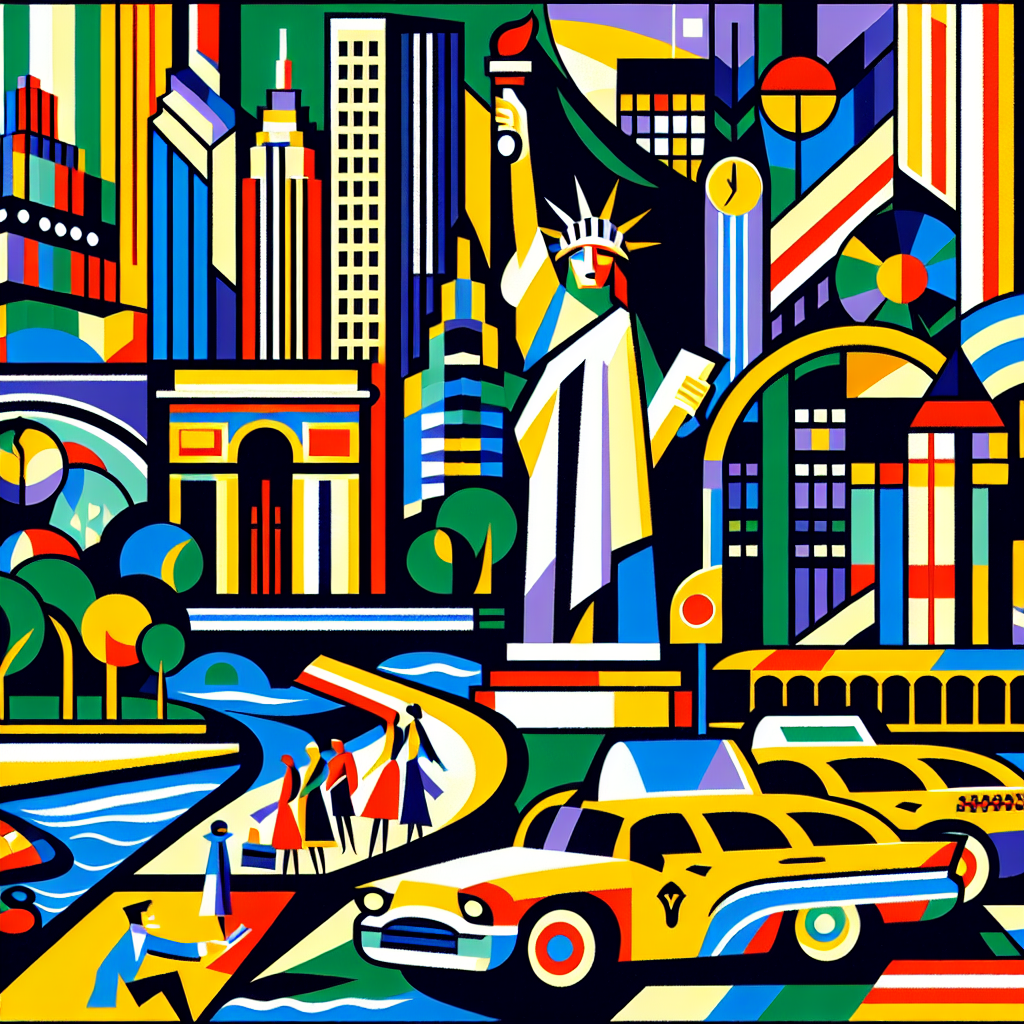

In [15]:
image = artist("New York City")
display(image)

In [16]:


def talker(message):
    response = openai.audio.speech.create(
        model="gpt-4o-mini-tts",
        voice='onyx',
        input=message
    )
    return response.content

## Combine them all together

In [30]:

tool_registry ={ 
    "get_ticket_price": get_ticket_price,
    "set_ticket_price": set_ticket_price
}

def handle_tool_calls_and_return_cities(message):
    responses = []
    cities = []
    for tool_call in message.tool_calls:
        function = tool_registry.get(tool_call.function.name)
        arguments = json.loads(tool_call.function.arguments)
        city =arguments.get('city')
        cities.append(city)
        result = function(**arguments)

        responses.append({
            "role": "tool",
            "content": str(result),
            "tool_call_id": tool_call.id,
        })
    return responses, cities

In [31]:
def chat(history):
    history = [{"role":h["role"], "content":h["content"]} for h in history]
    messages = [{"role":"system", "content":system_message}] + history
    response = openai.chat.completions.create(model=GPT_MODEL, messages=messages, tools=tools)
    cities = []
    image = None

    while response.choices[0].finish_reason == "tool_calls":
        message = response.choices[0].message
        responses, cities = handle_tool_calls_and_return_cities(message)
        messages.append(message)
        messages.extend(responses)
        response = openai.chat.completions.create(model=GPT_MODEL, messages = messages, tools = tools)

    reply = response.choices[0].message.content
    history += [{"role": "assistant", "content": reply}]

    voice = talker(reply)

    if cities:
        image=artist(cities[0])

    return history, voice, image

In [32]:
def put_message_in_chatbot(message, history):
        return "", history + [{"role":"user", "content":message}]

# UI definition

with gr.Blocks() as ui:
    with gr.Row():
        chatbot = gr.Chatbot(height=500, type="messages")
        image_output = gr.Image(height=500, interactive=False)
    with gr.Row():
        audio_output = gr.Audio(autoplay=True)
    with gr.Row():
        message = gr.Textbox(label="Chat with our AI Assistant:")

# Hooking up events to callbacks

    message.submit(put_message_in_chatbot, inputs=[message, chatbot], outputs=[message, chatbot]).then(
        chat, inputs=chatbot, outputs=[chatbot, audio_output, image_output]
    )

ui.launch() #inbrowser=True, auth=("ed", "bananas")

* Running on local URL:  http://127.0.0.1:7888
* To create a public link, set `share=True` in `launch()`.


DATABASE TOOL CALLED: Getting price for London
